In [46]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# load the low resolution world map
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

/var/folders/j8/w88cxj05115byx3n9mnk572w0000gn/T/ipykernel_58691/4146411044.py:7: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


* we can get the data directly from the source: https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip 
* dowload this file, unzip and read the shp file, or read the zip file directly

In [47]:
world1 = gpd.read_file("/Users/yingli/Downloads/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

In [48]:
world2 = gpd.read_file("zip:///Users/yingli/Downloads/ne_110m_admin_0_countries.zip")


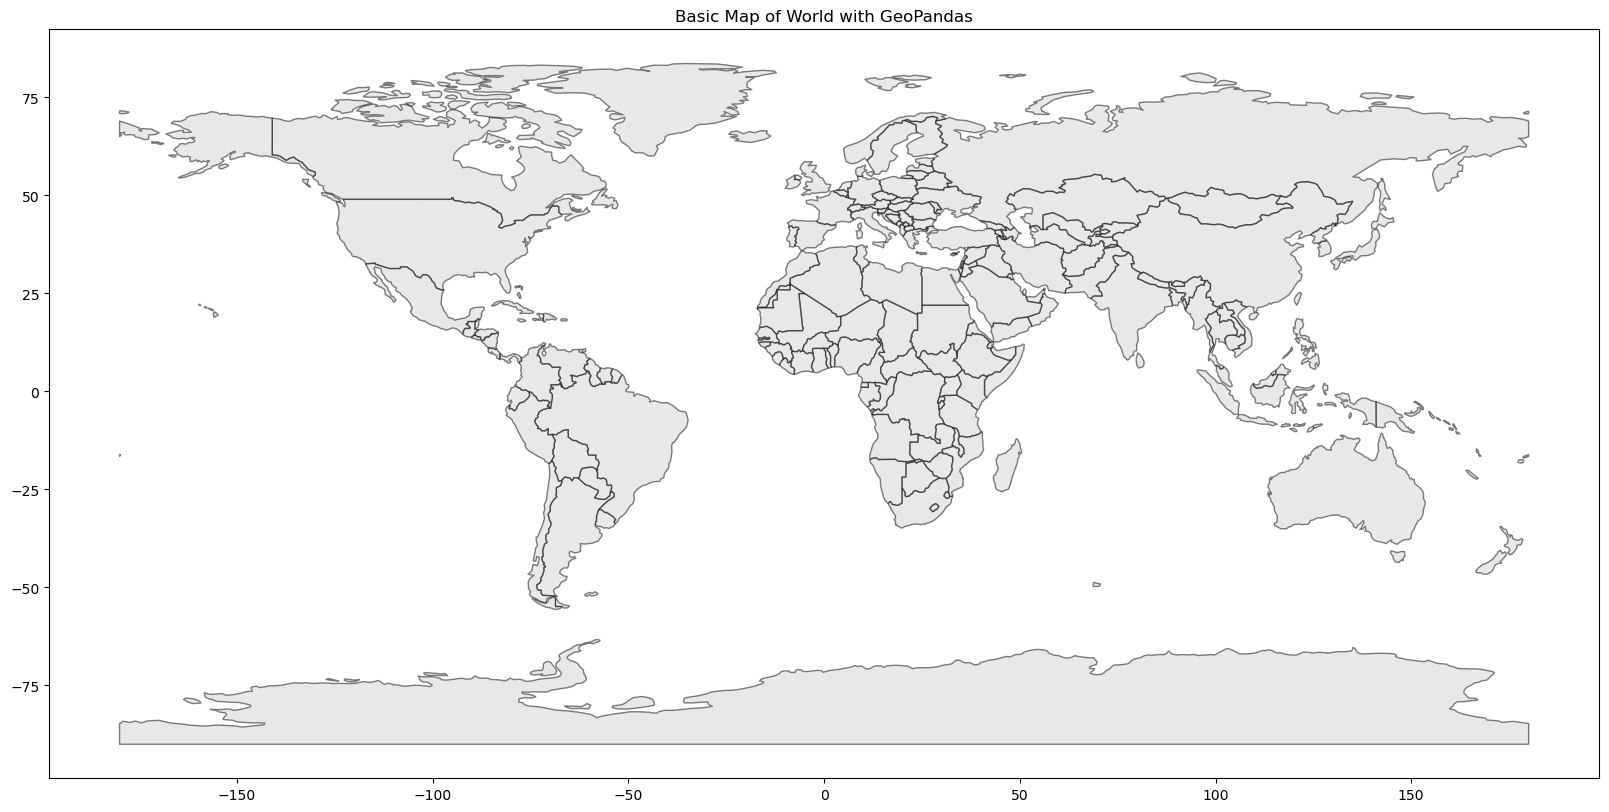

In [49]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()
world.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.5) #alpha for transparency
plt.title("Basic Map of World with GeoPandas")
plt.show()

In [50]:
world.columns[0:100]

Index(['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry'], dtype='object')

* Drop row for 'Antarctica'. It takes a lot of space in the map and is not of much use


* if reading data directly from the natural earth website, the column names are in upper case

<Axes: >

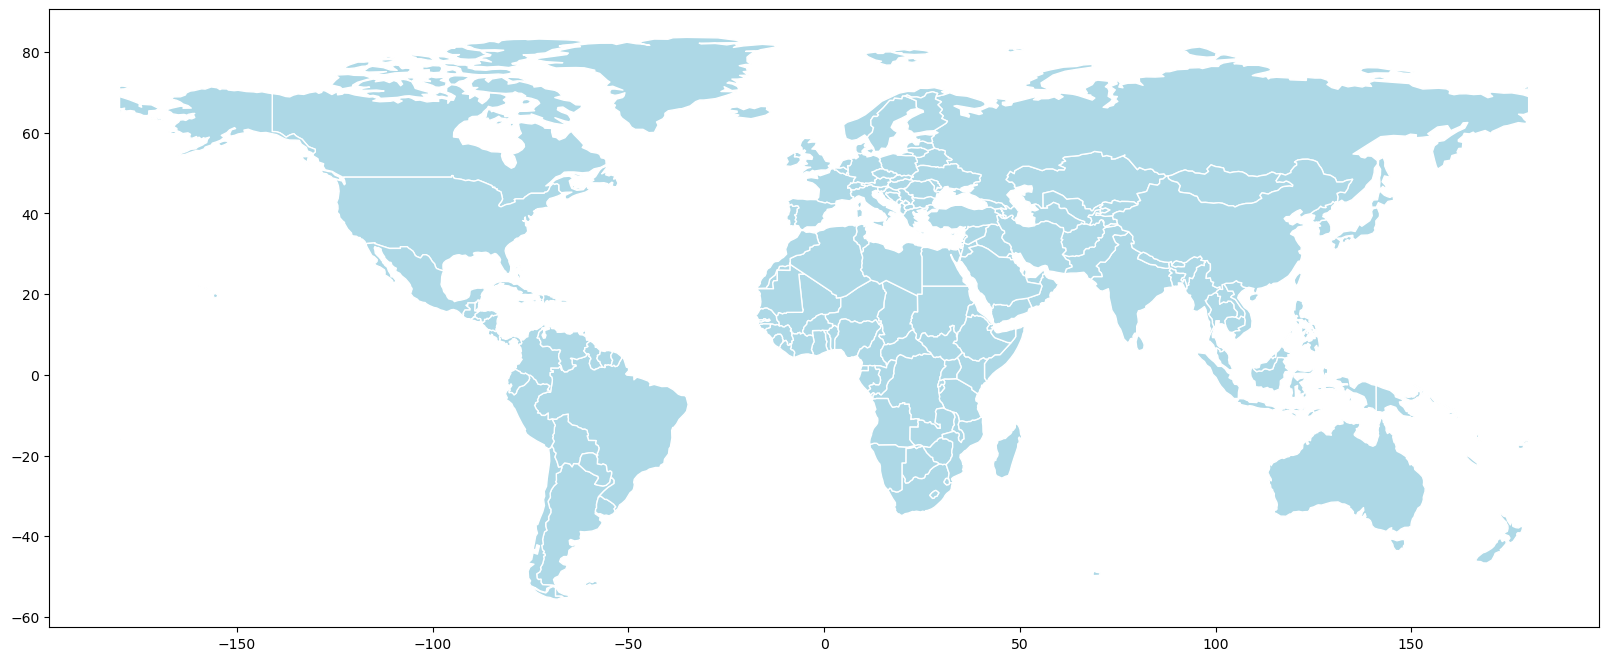

In [55]:
world1= world1.drop(world1.loc[world1['CONTINENT'] == 'Antarctica'].index)
world1.plot(figsize=(20, 20), edgecolor='white', linewidth=1, color='lightblue')

In [56]:
world

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."
...,...,...,...,...,...,...
172,6944975.0,Europe,Serbia,SRB,51475,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,622137.0,Europe,Montenegro,MNE,5542,"POLYGON ((20.07070 42.58863, 19.80161 42.50009..."
174,1794248.0,Europe,Kosovo,-99,7926,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,1394973.0,North America,Trinidad and Tobago,TTO,24269,"POLYGON ((-61.68000 10.76000, -61.10500 10.890..."


<Axes: >

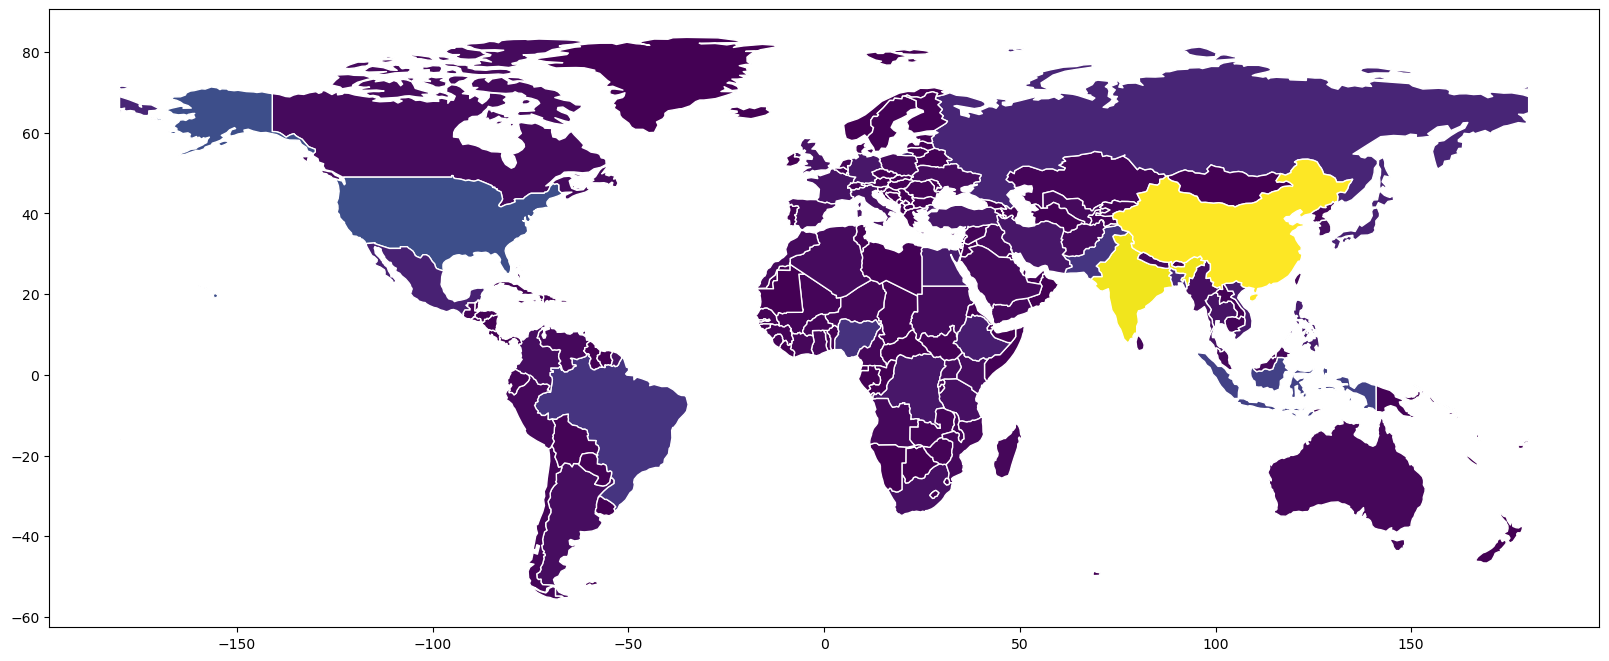

In [58]:
world= world.drop(world.loc[world['continent'] == 'Antarctica'].index)
world.plot(figsize=(20, 20)
           , column = 'pop_est'
           #, color='lightblue'
           , edgecolor='white'
           , linewidth=1
           )

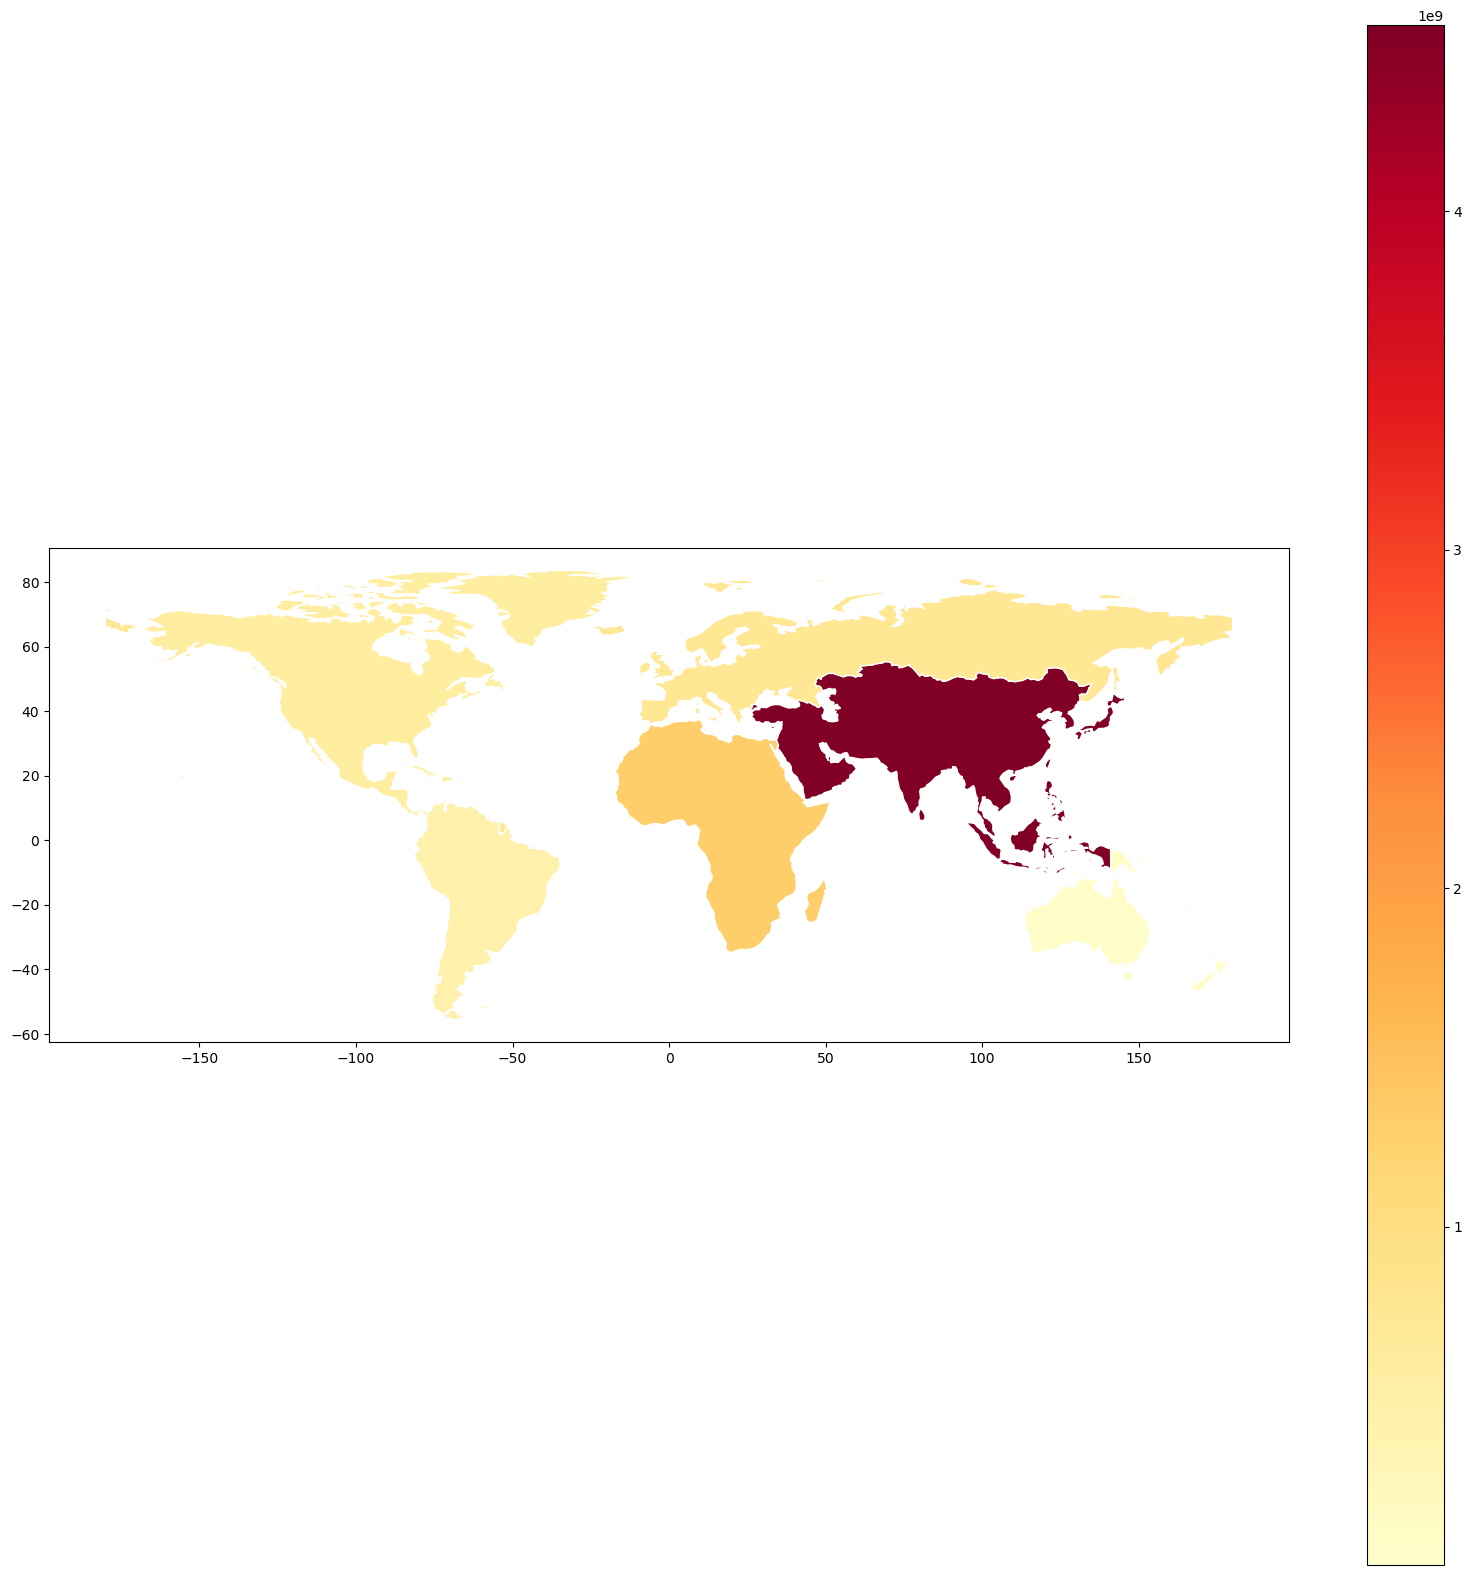

In [70]:
world = world.drop(world.loc[world['continent'] == 'Antarctica'].index)
continent = world[['pop_est','continent','geometry']].dissolve(by="continent", aggfunc='sum').plot(figsize=(20, 20)
           , column = 'pop_est'
           #, color='lightblue' # either column or color, not both
           , edgecolor='white'
           , linewidth=1
           , cmap = 'YlOrRd'
           , legend = True
           )